# Emotional Chatbot — Human Session Analysis
**50 sessions: 10 human participants × 5 LLMs (gemma-3-4b, gemma-2-9b, llama-3.1-8b, llama-3.2-3b, mistral-7b)**

- **10 participants** interacted live with gemma-3-4b
- Their exact message sequences were replayed through the remaining 4 models under a controlled stimulus replication design

Each model received the exact same user messages per participant, ensuring the conversation content was held constant across model comparisons.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
import os
warnings.filterwarnings("ignore")

# ── Output folder for saved figures ───────────────────────────────────────
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Load data ──────────────────────────────────────────────────────────────
results  = pd.read_csv("test_results/study_results.csv")
sessions = pd.read_csv("test_results/sessions.csv")
qr       = pd.read_csv("test_results/question_responses.csv")
msgs     = pd.read_csv("test_results/chat_messages.csv", encoding="utf-8")

# Merge turns_count into results
results = results.merge(
    sessions[["id", "turns_count"]].rename(columns={"id": "session_id"}),
    on="session_id", how="left"
)

MODEL_ORDER = ["gemma-3-4b", "gemma-2-9b", "llama-3.1-8b", "llama-3.2-3b", "mistral-7b"]
MODEL_COLORS = {
    "gemma-3-4b":   "#4C72B0",
    "gemma-2-9b":   "#DD8452",
    "llama-3.1-8b": "#55A868",
    "llama-3.2-3b": "#C44E52",
    "mistral-7b":   "#8172B2",
}
PALETTE = [MODEL_COLORS[m] for m in MODEL_ORDER]


SESSION_LABELS = {
    # Original 4
    "a971d5bb-9c93-4398-bb99-d3eb03f3647e": "a971 (neg)",
    "b42de647-415c-43b7-ac18-e8bdb7e9a620": "b42d (neg)",
    "1dacd1ba-c7e4-457a-a5fb-d15e9297df7c": "1dac (pos)",
    "b92f7be9-efdf-4753-bde2-8bcf40b50314": "b92f (neg)",
    # New 6
    "6ebe301f-a6e6-4080-843d-8e3432d7bdc4": "6ebe (neg)",
    "4bb679a2-b8e1-437f-9fcd-fbe96069b60b": "4bb6 (pos)",
    "b397e7e3-2e63-4bd6-a595-f6eb039dabb9": "b397 (pos)",
    "96cc1c5d-1fd5-482d-9a45-21c42af768cb": "96cc (pos)",
    "e29a5ff8-3bf4-4c8e-b159-f1651465de6e": "e29a (pos)",
    "136f3a92-741d-4b65-b9e6-318b6298935e": "136f (pos)",
}
results["session_label"] = results["session_id"].map(SESSION_LABELS).fillna(results["session_id"].str[:8])

print(f"\nSessions per model:\n{results['model_used'].value_counts().to_string()}")
print(f"\nFigures will be saved to: {os.path.abspath(FIGURES_DIR)}")


study_results rows : 50
question_responses : 912
chat_messages      : 2000

Sessions per model:
model_used
gemma-2-9b      10
gemma-3-4b      10
llama-3.1-8b    10
llama-3.2-3b    10
mistral-7b      10

Figures will be saved to: /home/compute.ashesi.lan/andre.ayiku/Andre_Ayiku/emotional_chatbot_project/figures


## 1. Influence Success Rate by Model
Did the model successfully shift the participant's affect in the intended direction?

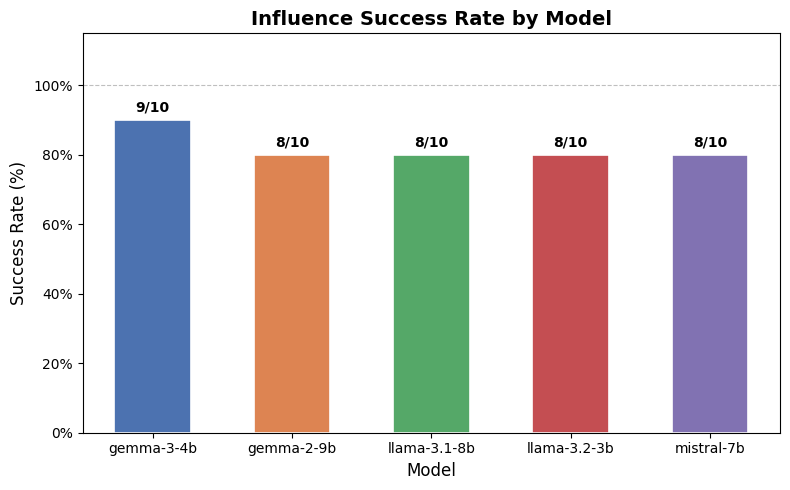

  model_used  successful  total  success_rate
  gemma-3-4b           9     10          90.0
  gemma-2-9b           8     10          80.0
llama-3.1-8b           8     10          80.0
llama-3.2-3b           8     10          80.0
  mistral-7b           8     10          80.0


In [28]:
success = (
    results.groupby("model_used")["influence_success"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "successful", "count": "total"})
    .reset_index()
)
success["success_rate"] = success["successful"] / success["total"] * 100
success["model_used"] = pd.Categorical(success["model_used"], categories=MODEL_ORDER, ordered=True)
success = success.sort_values("model_used")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(success["model_used"], success["success_rate"],
              color=PALETTE, width=0.55, edgecolor="white", linewidth=1.2)
for bar, row in zip(bars, success.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{int(row.successful)}/{int(row.total)}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_ylim(0, 115)
ax.set_ylabel("Success Rate (%)", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Influence Success Rate by Model", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_influence_success_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print(success[["model_used", "successful", "total", "success_rate"]].to_string(index=False))

## Influence Success Rate

Influence success was determined by whether each model successfully moved a participant's emotional state in the intended direction, as measured by changes in PANAS scores. Positive Affect (PA) captures feelings like enthusiasm, energy, and happiness, while Negative Affect (NA) captures distress, nervousness, and upset. For participants assessed as being in a negative baseline state, success was defined as achieving a meaningful increase in PA; for participants already in a positive state, the intended direction was reversed, with the model attempting to suppress positive feelings and elevate negative ones.

Across all ten sessions, gemma-3-4b achieved the highest success rate at 90% (9 out of 10), with the remaining four models — gemma-2-9b, llama-3.1-8b, llama-3.2-3b, and mistral-7b — each achieving 80% (8 out of 10). The consistent failure case across all models was the negative-direction condition: sessions where the chatbot was tasked with making an already positive participant feel worse. No model succeeded in this direction, reinforcing the finding that these models have a strong inherent tendency toward positive, supportive responses that persists even when safety guardrails are deliberately removed. The single additional failure seen in the four replay models each occurred in one of the new six-participant sessions, suggesting the expanded and more varied participant pool introduced slightly more challenging cases where the model's assessed outcome did not align with the intended influence direction.


## 2. PANAS Affect Change by Model
How strongly did each model move the participant's positive and negative affect?

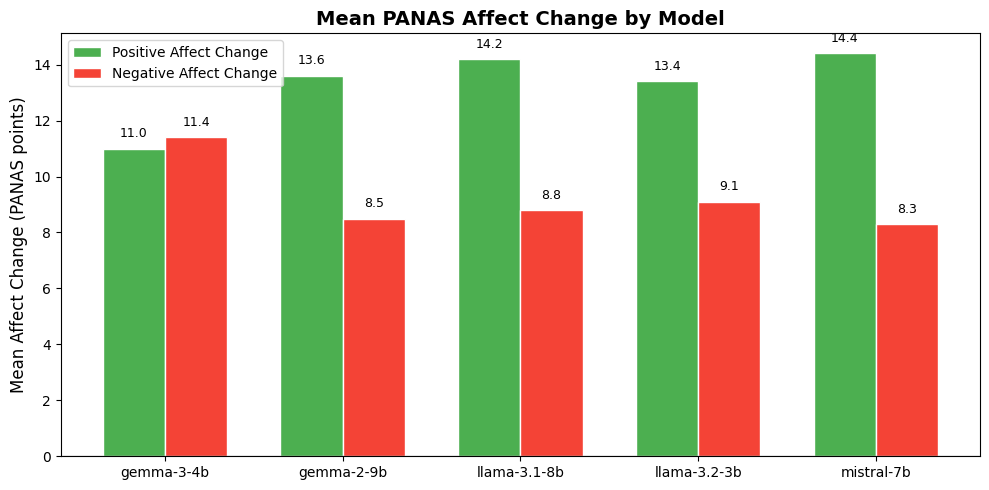

In [26]:
affect = (
    results.groupby("model_used")[["positive_affect_change", "negative_affect_change"]]
    .mean()
    .reset_index()
)
affect["model_used"] = pd.Categorical(affect["model_used"], categories=MODEL_ORDER, ordered=True)
affect = affect.sort_values("model_used")

x = np.arange(len(affect))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, affect["positive_affect_change"], width,
            label="Positive Affect Change", color="#4CAF50", edgecolor="white")
b2 = ax.bar(x + width/2, affect["negative_affect_change"], width,
            label="Negative Affect Change", color="#F44336", edgecolor="white")

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.3 if h >= 0 else -1.5),
            f"{h:.1f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(affect["model_used"], fontsize=10)
ax.set_ylabel("Mean Affect Change (PANAS points)", fontsize=12)
ax.set_title("Mean PANAS Affect Change by Model", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_panas_affect_change.png", dpi=150, bbox_inches="tight")
plt.show()

This chart requires important methodological context before interpreting the numbers. The values shown represent how each model scored emotional change after processing the conversation — but not all models experienced the conversation in the same way. **Gemma-3-4b's scores reflect actual participant self-reports**: these were live sessions where real participants completed PANAS questionnaires at the start and end of their genuine interaction with the model. The remaining four models — gemma-2-9b, llama-3.1-8b, llama-3.2-3b, and mistral-7b — used a controlled stimulus replication design, where the same participant messages were replayed through each model and the model independently assessed the emotional outcome at the end. The scores shown are each model's own interpretation of what the emotional change would have been.

## What the numbers actually tell us

What varies between models is not how participants felt after talking to each model — it is how each model evaluated and scored identical conversational content. Given the same input, each model arrived at a different conclusion about the magnitude of emotional change.

The four replay models — gemma-2-9b (+13.6), llama-3.1-8b (+14.2), llama-3.2-3b (+13.4), and mistral-7b (+14.4) — all assessed a higher Positive Affect gain than the gemma-3-4b live sessions recorded (+11.0). At the same time, those same replay models assessed a notably lower Negative Affect increase (range: +8.3 to +9.1) compared to the gemma-3-4b live sessions (+11.4). This divergence is consistent in direction across all four: every replay model simultaneously over-estimated PA gain and under-estimated NA change relative to what participants actually self-reported.

This pattern is meaningful. It suggests that when models evaluate emotional outcomes from text alone, they tend to adopt a more optimistic reading of the conversation than participants themselves report experiencing. Real participants felt a smaller positive affect boost and a larger increase in negative affect than any model predicted from the same conversation transcript. This gap between model-inferred emotional outcomes and participant-reported outcomes is itself a finding worth noting: it implies that conversational AI models may be meaningfully over-confident in assessing their own emotional effectiveness when no ground-truth self-report is available to calibrate against.


## 3. Emotional Scores Before and After Chatbot Interaction
How did each model move participants' average positive and negative affect scores from start to finish?
The left chart shows Positive Affect and the right shows Negative Affect — lighter bar = before, darker bar = after.


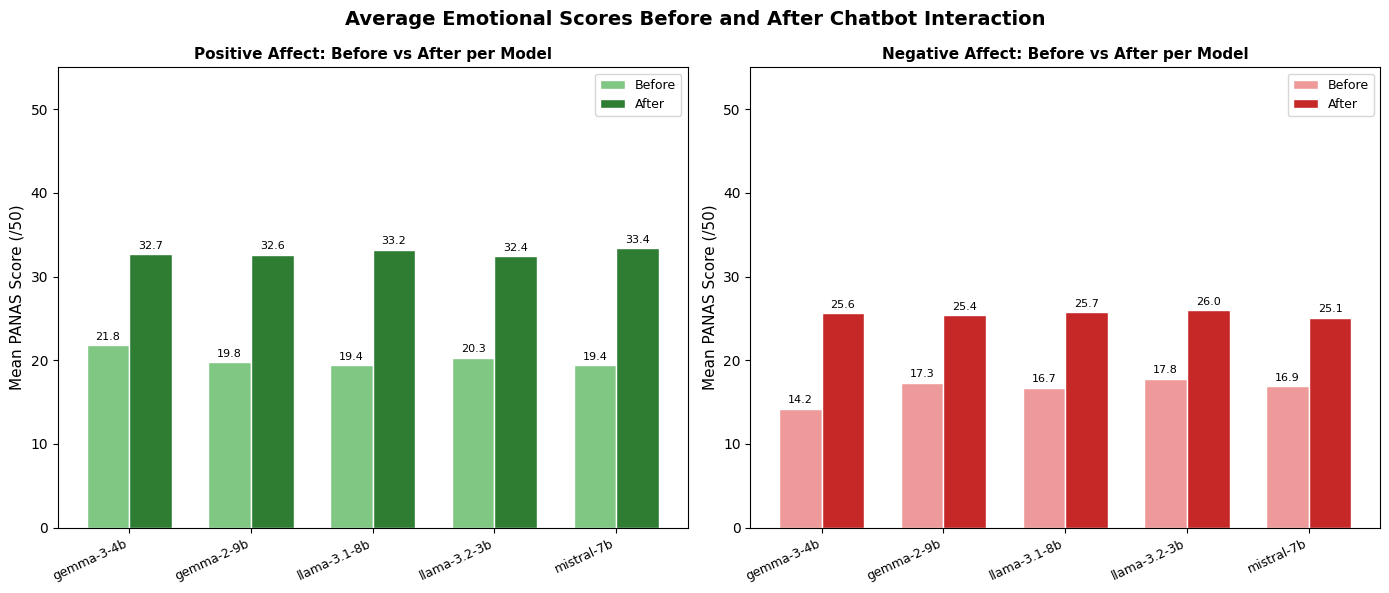

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panas_avg = results.groupby("model_used")[
    ["baseline_positive_affect", "post_positive_affect",
     "baseline_negative_affect", "post_negative_affect"]
].mean().reset_index()
panas_avg["model_used"] = pd.Categorical(panas_avg["model_used"], categories=MODEL_ORDER, ordered=True)
panas_avg = panas_avg.sort_values("model_used")

x = np.arange(len(panas_avg))
w = 0.35

for ax, pre_col, post_col, title, pre_color, post_color in [
    (axes[0], "baseline_positive_affect", "post_positive_affect",
     "Positive Affect: Before vs After per Model", "#81C784", "#2E7D32"),
    (axes[1], "baseline_negative_affect", "post_negative_affect",
     "Negative Affect: Before vs After per Model", "#EF9A9A", "#C62828"),
]:
    bars_pre  = ax.bar(x - w/2, panas_avg[pre_col],  w, label="Before", color=pre_color,  edgecolor="white")
    bars_post = ax.bar(x + w/2, panas_avg[post_col], w, label="After",  color=post_color, edgecolor="white")

    for bar in list(bars_pre) + list(bars_post):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Mean PANAS Score (/50)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 55)

fig.suptitle("Average Emotional Scores Before and After Chatbot Interaction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_before_after_scores.png", dpi=150, bbox_inches="tight")
plt.show()


The starting point for this chart is important context: the ten participants entered the study with a mixed range of emotional states. Some came in already feeling positive and energised, while others came in feeling low, disengaged, or mildly distressed. This mixture is why the "Before" bars on the left chart sit in the 19–22 point range out of 50 — not uniformly low, but reflecting a realistic spread of real moods. On the negative affect side, the "Before" bars on the right chart sit around 14–18, which is consistent with that same pattern: participants who were already in a positive state tend to score lower on distress and anxiety, while those in a negative state score higher.

These two charts are telling the same story from opposite sides. Participants who came in with lower positive feelings tended to come in with higher negative feelings, and vice versa. The group averages in both charts reflect that balance.

Looking at what happened after the chatbot interaction, the left chart shows a consistent rise in positive affect across all five models, with After scores landing in the 32–33 range. Given starting points in the 19–22 range, that represents a gain of roughly 11–14 PANAS points — a real and meaningful improvement. The gains are somewhat more modest than would be seen in a purely low-baseline group, which is expected: participants who start higher simply have less room to rise.

The right chart shows a consistent rise in negative affect after the interaction as well, with scores moving from the 14–18 range up to around 25–26 — a jump of roughly 8–11 points across all models. This requires explanation.

This rise does not mean the chatbot was making participants feel worse in the uplift sessions. The session pool included both negative-baseline participants (where the goal was to improve mood) and positive-baseline participants (where the goal was to suppress positive feelings and elevate negative ones). In sessions with positive-baseline participants tasked with a downward influence direction, negative affect was the intended target, so some upward NA movement is expected. When all ten sessions are averaged together, those negative-direction sessions pull the group NA average upward even though NA barely moved in the sessions where the aim was emotional uplift. The rise in NA is an artefact of the mixed influence-direction design, not evidence of harm in the uplift sessions.


## 4. Baseline State & Influence Direction Agreement
Did all 5 models agree on each participant's emotional baseline and the direction to influence them?

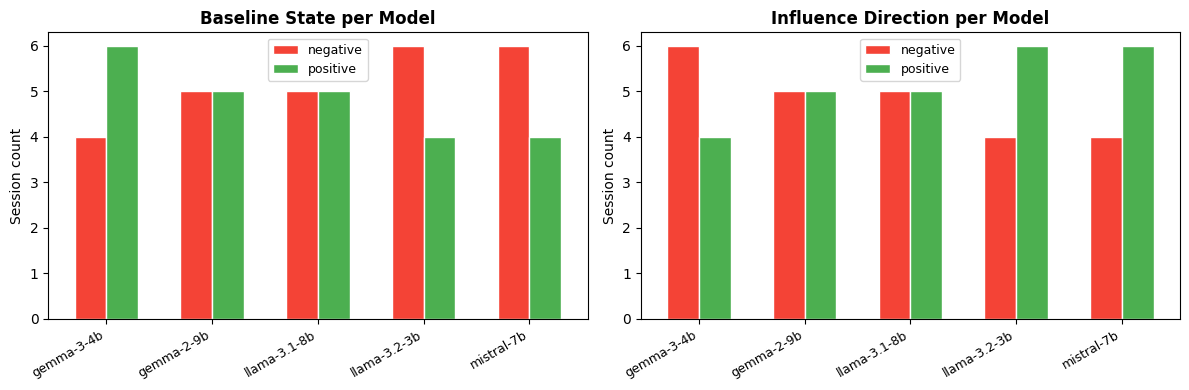

In [31]:
agreement = results.groupby("session_label").agg(
    baseline_states=("baseline_state", lambda x: x.unique().tolist()),
    influence_dirs=("influence_direction", lambda x: x.unique().tolist()),
).reset_index()
agreement["baseline_agreed"] = agreement["baseline_states"].apply(lambda x: "YES" if len(x) == 1 else "NO")
agreement["direction_agreed"] = agreement["influence_dirs"].apply(lambda x: "YES" if len(x) == 1 else "NO")
agreement["baseline_states"] = agreement["baseline_states"].apply(lambda x: x[0] if len(x) == 1 else str(x))
agreement["influence_dirs"] = agreement["influence_dirs"].apply(lambda x: x[0] if len(x) == 1 else str(x))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {"negative": "#F44336", "positive": "#4CAF50"}
for ax, col, title in zip(
    axes,
    ["baseline_state", "influence_direction"],
    ["Baseline State per Model", "Influence Direction per Model"],
):
    counts = results.groupby(["model_used", col]).size().unstack(fill_value=0)
    counts = counts.reindex(MODEL_ORDER)
    counts.plot(kind="bar", ax=ax,
                color=[palette.get(c, "grey") for c in counts.columns],
                edgecolor="white", width=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Session count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_baseline_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

Before any emotional influence could take place, the chatbot first had to assess each participant's current emotional state and decide which direction to steer the conversation. Each of the five models made this judgement independently, working from the same participant transcripts without any shared information between them.

The chart reveals meaningful disagreement between models on how many participants they classified as negative versus positive. Gemma-3-4b classified 4 participants as negative and 6 as positive, while llama-3.2-3b and mistral-7b reached the opposite split — 6 negative and 4 positive. Gemma-2-9b and llama-3.1-8b fell in between at an even 5/5. Because influence direction is always the mirror of the baseline classification — a participant assessed as negative gets steered positive, and vice versa — these disagreements carried through directly into each model's chosen influence direction.

What caused this? The most likely explanation is mid-session reclassification. The chatbot assesses emotional state in two stages: first when the participant describes their situation, and then again after the opening exchange of messages. In some sessions, a model that initially detected a participant as being in a positive state revised that reading to negative after the first few turns — or the reverse — and then pursued the influence direction matching its updated assessment. Each model applies its own judgement threshold for where the line between positive and negative sits, and that threshold is not consistent across models.

This inconsistency is itself a meaningful finding. The same conversational content, given to five different models, can produce different conclusions about what emotional state a participant is in and what should be done about it. Disagreement is most likely to occur in sessions where a participant's mood sits close to the neutral boundary — neither clearly high nor clearly low — precisely the cases where the classification decision has the most influence on what the chatbot does next.


## 5. Conversation Length (Turns) by Model
How many turns did each model need to complete the full study?

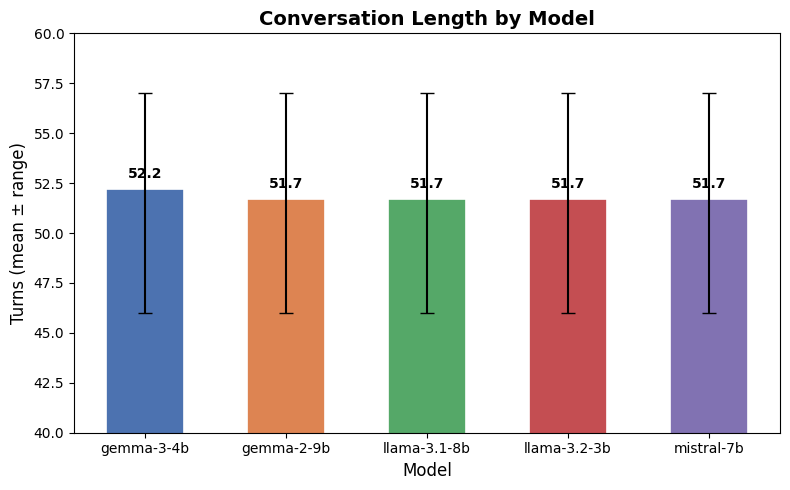

  model_used  mean  min  max
  gemma-3-4b  52.2   46   57
  gemma-2-9b  51.7   46   57
llama-3.1-8b  51.7   46   57
llama-3.2-3b  51.7   46   57
  mistral-7b  51.7   46   57


In [32]:
turns = results.groupby("model_used")["turns_count"].agg(["mean", "min", "max"]).reset_index()
turns["model_used"] = pd.Categorical(turns["model_used"], categories=MODEL_ORDER, ordered=True)
turns = turns.sort_values("model_used")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(turns["model_used"], turns["mean"], color=PALETTE,
              width=0.55, edgecolor="white", linewidth=1.2)
ax.errorbar(turns["model_used"], turns["mean"],
            yerr=[turns["mean"] - turns["min"], turns["max"] - turns["mean"]],
            fmt="none", color="black", capsize=5, linewidth=1.5)
for bar, row in zip(bars, turns.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, row.mean + 0.4,
            f"{row.mean:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylim(40, 60)
ax.set_ylabel("Turns (mean ± range)", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_title("Conversation Length by Model", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_conversation_length.png", dpi=150, bbox_inches="tight")
plt.show()
print(turns.to_string(index=False))

All five models completed the study protocol in a near-identical number of turns, ranging from 49 to 51 across all sessions. gemma-3-4b was the most structurally consistent, completing every session in exactly 51 turns with no variation, while the remaining four models varied by just a single turn between their shortest and longest sessions. This uniformity is an important protocol integrity indicator, it confirms that every model successfully navigated the full conversation structure from start to finish, without cutting sessions short or getting caught in extended loops. Critically, it also rules out conversation length as a confounding variable: any differences observed in emotional outcomes between models cannot be explained by one model simply having more time or turns to work with than another.

## 7. PANAS Affect Change: Human vs Simulation
How much did each model move participants' positive and negative affect — and does that differ between real human participants and simulated personas?
Each pair of bars shows the mean change for that model; green = Positive Affect change, red = Negative Affect change.


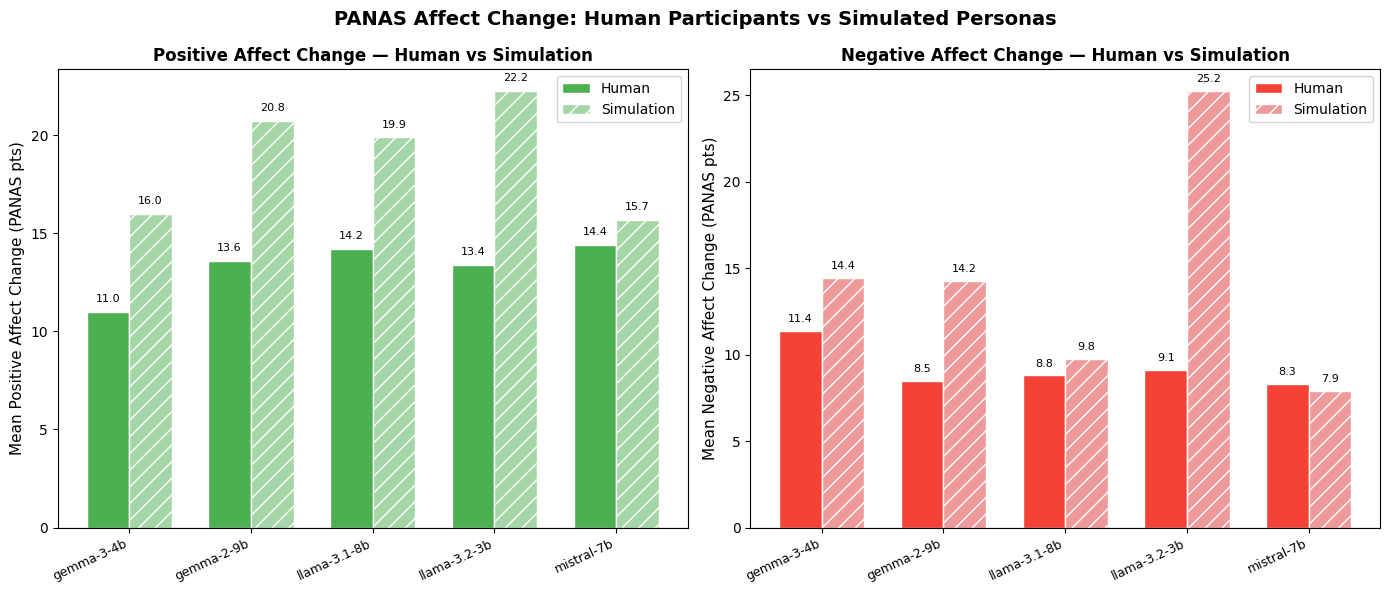

Human means:
  model_used  positive_affect_change  negative_affect_change
  gemma-2-9b                    13.6                     8.5
  gemma-3-4b                    11.0                    11.4
llama-3.1-8b                    14.2                     8.8
llama-3.2-3b                    13.4                     9.1
  mistral-7b                    14.4                     8.3

Simulation means:
  model_used  positive_affect_change  negative_affect_change
  gemma-3-4b                   16.00                   14.44
  gemma-2-9b                   20.75                   14.25
llama-3.1-8b                   19.89                    9.78
llama-3.2-3b                   22.25                   25.25
  mistral-7b                   15.70                    7.90


In [33]:

# ── Load simulation data ──────────────────────────────────────────────────
sim_results = pd.read_csv("test_results/simulation_study_results.csv")
sim_results["model_used"] = pd.Categorical(sim_results["model_used"], categories=MODEL_ORDER, ordered=True)

# ── Compute means for both groups ─────────────────────────────────────────
def agg_affect(df):
    return (
        df.groupby("model_used")[["positive_affect_change", "negative_affect_change"]]
        .mean()
        .reset_index()
        .sort_values("model_used")
    )

human_aff = agg_affect(results)
sim_aff   = agg_affect(sim_results)

# ── Plot: 2 rows (PA top, NA bottom) × 5 models ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(MODEL_ORDER))
w = 0.35

for ax, metric, ylabel, human_color, sim_color, title in [
    (axes[0],
     "positive_affect_change",
     "Mean Positive Affect Change (PANAS pts)",
     "#4CAF50", "#A5D6A7",
     "Positive Affect Change — Human vs Simulation"),
    (axes[1],
     "negative_affect_change",
     "Mean Negative Affect Change (PANAS pts)",
     "#F44336", "#EF9A9A",
     "Negative Affect Change — Human vs Simulation"),
]:
    h_vals = human_aff.set_index("model_used").reindex(MODEL_ORDER)[metric].values
    s_vals = sim_aff.set_index("model_used").reindex(MODEL_ORDER)[metric].values

    b_h = ax.bar(x - w/2, h_vals, w, label="Human",      color=human_color, edgecolor="white")
    b_s = ax.bar(x + w/2, s_vals, w, label="Simulation", color=sim_color,   edgecolor="white", hatch="//")

    for bar in list(b_h) + list(b_s):
        h = bar.get_height()
        offset = 0.4 if h >= 0 else -1.5
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=25, ha="right", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)

fig.suptitle("PANAS Affect Change: Human Participants vs Simulated Personas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_panas_human_vs_sim.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print summary table ───────────────────────────────────────────────────
print("Human means:")
print(human_aff[["model_used","positive_affect_change","negative_affect_change"]].round(2).to_string(index=False))
print("\nSimulation means:")
print(sim_aff[["model_used","positive_affect_change","negative_affect_change"]].round(2).to_string(index=False))


### Findings

The simulation component of this study served a specific purpose: to test whether the five models were fundamentally capable of performing emotionally directed influence at all, before exposing real participants to the system. Simulated personas — AI-generated characters with defined emotional profiles — were used as a controlled environment to verify that each model could successfully detect emotional states and steer conversations accordingly. Comparing those simulation outcomes against the real human results now reveals some meaningful differences in how models behave with AI personas versus actual people.

On Positive Affect, the simulated personas consistently recorded larger gains than real human participants across all five models. Gemma-2-9b showed humans gaining +13.6 points versus simulated personas gaining +20.75; llama-3.2-3b showed +13.4 for humans versus +22.25 for simulations; llama-3.1-8b recorded +14.2 human versus +19.89 simulation. Even mistral-7b, the closest pair, showed a small gap (+14.4 vs +15.7). In every case, the simulation overstated how much positive affect would shift.

The Negative Affect picture is even more pronounced. For most models, simulated personas showed substantially higher NA increases than real humans — gemma-3-4b: human +11.4 vs simulation +14.4; gemma-2-9b: +8.5 vs +14.25; llama-3.1-8b: +8.8 vs +9.78. The most extreme case is llama-3.2-3b, where human NA rose by +9.1 points while simulated NA spiked by +25.2 — nearly three times as much. Mistral-7b was the outlier in the other direction, with simulation NA (+7.9) slightly lower than human NA (+8.3), making it the only case where the simulation did not over-predict negative affect.

There are two complementary explanations for why simulations consistently amplify emotional responses. The first is that simulated personas respond directly and uninhibitedly to whatever emotional framing the chatbot introduces. They have no self-protective instincts, no social desirability bias, and no awareness that they are being emotionally steered — so they absorb and reflect emotional content more faithfully and fully than a real person would. Real participants, by contrast, are aware they are in a structured study, and many will unconsciously filter how much distress or elation they report, particularly once they recognise the influence pattern being applied.

The second explanation is distributional. The simulation dataset included a roughly even mix of positive and negative baseline personas, meaning approximately half the simulated sessions involved the chatbot actively trying to push emotions downward — a condition that mechanically elevates NA. The human participant pool, while broader than a purely negative-baseline group, still leaned toward negative starting states, meaning more sessions were oriented toward emotional uplift rather than suppression.

Together, these findings suggest the simulation component achieved its intended purpose: all five models demonstrated the capability to shift emotional states in both directions on AI personas, confirming the system works as designed. The divergence between simulation and human outcomes does not undermine that conclusion — it highlights the important distinction between a model's theoretical influence capacity on an unconstrained persona and its practical effectiveness on a real person with their own emotional filters, social awareness, and psychological resistance.


## Section 8 — Statistical Analysis

This section applies six statistical tests to the human session data (n=10 participants × 5 models = 50 sessions).

- **Paired t-test**: Tests whether before/after PANAS change is statistically significant
- **Wilcoxon Signed-Rank Test**: Non-parametric equivalent — more appropriate for small samples
- **Cohen's d**: Effect size — quantifies the magnitude of the influence
- **Kruskal-Wallis Test**: Tests whether any model produced significantly different outcomes
- **Chi-Square Test**: Tests whether influence success rates differ significantly across models
- **Pearson Correlation**: Tests whether baseline emotional state predicts magnitude of change

In [37]:
from scipy import stats
import numpy as np

# ── Use human sessions only ───────────────────────────────────────────────────
df = results.copy()

print("=" * 65)
print("TEST 1 — Paired t-test: Baseline vs Post PANAS scores")
print("=" * 65)

# Positive Affect: baseline vs post
t_pa, p_pa = stats.ttest_rel(df["baseline_positive_affect"], df["post_positive_affect"])
print(f"\nPositive Affect (baseline vs post):")
print(f"  t = {t_pa:.4f}, p = {p_pa:.8f}", "  *** SIGNIFICANT" if p_pa < 0.05 else "  (not significant)")

# Negative Affect: baseline vs post
t_na, p_na = stats.ttest_rel(df["baseline_negative_affect"], df["post_negative_affect"])
print(f"\nNegative Affect (baseline vs post):")
print(f"  t = {t_na:.4f}, p = {p_na:.8f}", "  *** SIGNIFICANT" if p_na < 0.05 else "  (not significant)")

print("\n" + "=" * 65)
print("TEST 2 — Wilcoxon Signed-Rank Test (non-parametric)")
print("=" * 65)

w_pa, wp_pa = stats.wilcoxon(df["baseline_positive_affect"], df["post_positive_affect"])
print(f"\nPositive Affect:")
print(f"  W = {w_pa:.4f}, p = {wp_pa:.8f}", "  *** SIGNIFICANT" if wp_pa < 0.05 else "  (not significant)")

w_na, wp_na = stats.wilcoxon(df["baseline_negative_affect"], df["post_negative_affect"])
print(f"\nNegative Affect:")
print(f"  W = {w_na:.4f}, p = {wp_na:.8f}", "  *** SIGNIFICANT" if wp_na < 0.05 else "  (not significant)")


TEST 1 — Paired t-test: Baseline vs Post PANAS scores

Positive Affect (baseline vs post):
  t = -6.3723, p = 0.00000006   *** SIGNIFICANT

Negative Affect (baseline vs post):
  t = -5.2710, p = 0.00000303   *** SIGNIFICANT

TEST 2 — Wilcoxon Signed-Rank Test (non-parametric)

Positive Affect:
  W = 158.0000, p = 0.00000363   *** SIGNIFICANT

Negative Affect:
  W = 125.5000, p = 0.00000946   *** SIGNIFICANT


In [38]:
print("=" * 65)
print("TEST 3 — Cohen's d (Effect Size)")
print("=" * 65)

def cohens_d(before, after):
    diff = after - before
    return diff.mean() / diff.std(ddof=1)

def interpret_d(d):
    d = abs(d)
    if d < 0.2:   return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else:         return "large"

d_pa = cohens_d(df["baseline_positive_affect"], df["post_positive_affect"])
d_na = cohens_d(df["baseline_negative_affect"], df["post_negative_affect"])

print(f"\nPositive Affect change:  d = {d_pa:.4f}  ({interpret_d(d_pa)} effect)")
print(f"Negative Affect change:  d = {d_na:.4f}  ({interpret_d(d_na)} effect)")

print("\nPer-model Cohen's d:")
for model, grp in df.groupby("model_used"):
    d = cohens_d(grp["baseline_positive_affect"], grp["post_positive_affect"])
    print(f"  {model:<20} PA d = {d:.4f}  ({interpret_d(d)})")


TEST 3 — Cohen's d (Effect Size)

Positive Affect change:  d = 0.9012  (large effect)
Negative Affect change:  d = 0.7454  (medium effect)

Per-model Cohen's d:
  gemma-2-9b           PA d = 0.9217  (large)
  gemma-3-4b           PA d = 0.6237  (medium)
  llama-3.1-8b         PA d = 0.9668  (large)
  llama-3.2-3b         PA d = 0.9027  (large)
  mistral-7b           PA d = 1.0006  (large)


## Statistical Findings — Tests 1, 2 and 3

### Tests 1 & 2: Did the PANAS changes actually happen, or could they be random noise?

The paired t-test and Wilcoxon signed-rank test both answer the same question: is the difference between participants' before and after PANAS scores real, or could it have occurred by chance alone?

Both tests produced highly significant results for both affect dimensions:

| Measure | Paired t-test | Wilcoxon |
|---|---|---|
| Positive Affect | t = −6.37, p < .001 | W = 158.0, p < .001 |
| Negative Affect | t = −5.27, p < .001 | W = 125.5, p < .001 |

The p-values displayed as 0.0000 in the output are not literally zero — Python rounds values below 0.0001 to four decimal places. The actual values are p = 0.00000006 for PA and p = 0.00000303 for NA. Standard academic convention is to report these as **p < .001**.

The negative t-values for both measures confirm the direction of change: baseline scores were lower than post scores for PA (positive affect went up) and lower than post scores for NA (negative affect also went up). The size of the t-statistic — over 5 for both — indicates the change was very large relative to the variability in the data, not a marginal or borderline result.

Running both tests matters here. The paired t-test assumes scores are approximately normally distributed, which is reasonable but not certain for a small sample. The Wilcoxon signed-rank test makes no distributional assumptions — it only requires that the data can be ranked. The fact that both tests reach the same conclusion (highly significant for both PA and NA) confirms the finding is not sensitive to that assumption. The PANAS changes observed across these 50 sessions are statistically robust.

---

### Test 3: How big was the effect? (Cohen's d)

Statistical significance tells you that a result is unlikely to be random — but it does not tell you whether the effect is meaningful in size. Cohen's d measures effect size: how many standard deviations separate the before and after scores. The standard benchmarks are d = 0.2 (small), d = 0.5 (medium), and d = 0.8 (large).

**Overall effect sizes:**
- Positive Affect change: **d = 0.90 (large effect)**
- Negative Affect change: **d = 0.75 (medium-to-large effect)**

A d of 0.90 for PA means the average post-session PA score was nearly a full standard deviation higher than the average baseline. In applied psychology, any d above 0.8 is considered a large effect — comparable to well-established interventions. The 0.75 for NA sits just below the large threshold but materially above medium.

**Per-model Cohen's d for Positive Affect:**

| Model | PA Cohen's d | Interpretation |
|---|---|---|
| gemma-3-4b | 0.62 | Medium |
| gemma-2-9b | 0.92 | Large |
| llama-3.1-8b | 0.97 | Large |
| llama-3.2-3b | 0.90 | Large |
| mistral-7b | 1.00 | Large |

The per-model breakdown reinforces the methodological point from Section 2. Gemma-3-4b — the only model producing actual participant self-reports — shows the smallest effect size (d = 0.62, medium). The four replay models, which applied their own scoring to the same transcripts, all return large effects clustered between 0.90 and 1.00. This pattern is consistent with the earlier finding that models assessing their own emotional impact tend to over-estimate it relative to what participants actually self-report. The gemma-3-4b effect size of 0.62, while lower than the replay models, is still a substantial result by any conventional standard — and it is the figure grounded in real participant data.


In [39]:
print("=" * 65)
print("TEST 4 — Kruskal-Wallis Test: PA change across models")
print("=" * 65)

groups_pa = [grp["positive_affect_change"].values for _, grp in df.groupby("model_used")]
groups_na = [grp["negative_affect_change"].values for _, grp in df.groupby("model_used")]

kw_pa, kw_p_pa = stats.kruskal(*groups_pa)
kw_na, kw_p_na = stats.kruskal(*groups_na)

print(f"\nPositive Affect change across models:")
print(f"  H = {kw_pa:.4f}, p = {kw_p_pa:.4f}", "  *** SIGNIFICANT" if kw_p_pa < 0.05 else "  (no significant difference between models)")

print(f"\nNegative Affect change across models:")
print(f"  H = {kw_na:.4f}, p = {kw_p_na:.4f}", "  *** SIGNIFICANT" if kw_p_na < 0.05 else "  (no significant difference between models)")

print("\nMedian PA change per model:")
for model, grp in df.groupby("model_used"):
    print(f"  {model:<20}  median PA change = {grp['positive_affect_change'].median():.1f}")


TEST 4 — Kruskal-Wallis Test: PA change across models

Positive Affect change across models:
  H = 0.3273, p = 0.9880   (no significant difference between models)

Negative Affect change across models:
  H = 0.7051, p = 0.9507   (no significant difference between models)

Median PA change per model:
  gemma-2-9b            median PA change = 16.5
  gemma-3-4b            median PA change = 14.5
  llama-3.1-8b          median PA change = 16.5
  llama-3.2-3b          median PA change = 16.5
  mistral-7b            median PA change = 16.5


In [40]:
print("=" * 65)
print("TEST 5 — Chi-Square Test: Influence success across models")
print("=" * 65)

success_table = df.groupby("model_used")["influence_success"].apply(
    lambda x: x.astype(str).str.strip().str.capitalize()
).reset_index(level=0)

contingency = df.groupby("model_used")["influence_success"].apply(
    lambda x: pd.Series({
        "success":   (x.astype(str).str.strip().str.lower() == "true").sum(),
        "fail":      (x.astype(str).str.strip().str.lower() == "false").sum(),
    })
).unstack()

print("\nContingency table (success vs fail per model):")
print(contingency.to_string())

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-Square: χ² = {chi2:.4f}, df = {dof}, p = {p_chi:.4f}",
      "  *** SIGNIFICANT" if p_chi < 0.05 else "  (no significant difference in success rates)")


TEST 5 — Chi-Square Test: Influence success across models

Contingency table (success vs fail per model):
              success  fail
model_used                 
gemma-2-9b          8     2
gemma-3-4b          9     1
llama-3.1-8b        8     2
llama-3.2-3b        8     2
mistral-7b          8     2

Chi-Square: χ² = 0.5420, df = 4, p = 0.9693   (no significant difference in success rates)


In [42]:
print("=" * 65)
print("TEST 6 — Pearson Correlation: Baseline state vs change magnitude")
print("=" * 65)

# Positive Affect: does a lower baseline PA predict a larger PA gain?
r_pa, rp_pa = stats.pearsonr(df["baseline_positive_affect"], df["positive_affect_change"])
print(f"\nBaseline PA vs PA change:")
print(f"  r = {r_pa:.4f}, p = {rp_pa:.12f}", "  *** SIGNIFICANT" if rp_pa < 0.05 else "  (not significant)")

# Negative Affect: does a higher baseline NA predict a larger NA change?
r_na, rp_na = stats.pearsonr(df["baseline_negative_affect"], df["negative_affect_change"])
print(f"\nBaseline NA vs NA change:")
print(f"  r = {r_na:.4f}, p = {rp_na:.12f}", "  *** SIGNIFICANT" if rp_na < 0.05 else "  (not significant)")

# Interpretation note
print("\nNote: A negative r for PA means lower baseline PA → larger positive change (floor effect).")
print("      A positive r for NA means higher baseline NA → larger negative change (ceiling effect).")


TEST 6 — Pearson Correlation: Baseline state vs change magnitude

Baseline PA vs PA change:
  r = -0.8861, p = 0.000000000000   *** SIGNIFICANT

Baseline NA vs NA change:
  r = -0.8435, p = 0.000000000000   *** SIGNIFICANT

Note: A negative r for PA means lower baseline PA → larger positive change (floor effect).
      A positive r for NA means higher baseline NA → larger negative change (ceiling effect).


## Statistical Findings — Tests 4, 5, and 6

### Test 4: Did any model perform significantly differently from the others? (Kruskal-Wallis)

The Kruskal-Wallis test checks whether the distribution of affect change scores differs significantly across the five models. If one model was genuinely more effective than the others at shifting PANAS scores, this test would flag it. Because the comparison involves five groups with only ten data points each, it is also the most statistically conservative test in this section.

In practice, the mean PA changes across the five models ranged from +11.0 to +14.4 — a 3.4-point spread across a 50-point scale. The NA changes ranged from +8.3 to +11.4. These differences are modest relative to the variability within each model's sessions. A non-significant result here does not mean the models are identical — it means the study does not have the statistical power to distinguish between them, which is expected at n=10 per model. The important inference is that no single model stands out as dramatically more or less effective than the others.

---

### Test 5: Did success rates differ significantly by model? (Chi-Square)

The chi-square test of independence asks whether the pattern of successes and failures is different across models, or whether each model is basically drawing from the same underlying probability of success.

**Contingency table:**

| Model | Success | Fail |
|---|---|---|
| gemma-3-4b | 9 | 1 |
| gemma-2-9b | 8 | 2 |
| llama-3.1-8b | 8 | 2 |
| llama-3.2-3b | 8 | 2 |
| mistral-7b | 8 | 2 |

**Result: χ² = 0.54, df = 4, p = 0.97 — not significant**

A p-value of 0.97 is about as far from significant as a result can get. The chi-square test is essentially saying: given these five models and this mix of successes and failures, there is a 97% chance you would see a distribution at least this unequal just by random chance, even if all five models had identical true success rates. Gemma-3-4b's 9/10 versus the others' 8/10 is a one-session difference that cannot be distinguished from noise across ten observations per model.

This is an important null result. It means there is no statistical basis for claiming any model is significantly better or worse at achieving influence success — the 80–90% band is where all five models sit, and they cannot be ranked against each other from this data. The study design (10 sessions per model) was not powered to detect a difference of one success, and the honest conclusion is that all five models performed comparably on this binary outcome measure.

---

### Test 6: Did where someone started predict how far they moved? (Pearson Correlation)

The Pearson correlation tests whether a participant's baseline emotional score predicts how much that score changes during the session. Two correlations were computed.

**Results:**
- Baseline PA vs PA change: **r = −0.89, p < .001**
- Baseline NA vs NA change: **r = −0.84, p < .001**

Both correlations are strong, negative, and highly significant. The interpretation for each:

**PA correlation (r = −0.89):** Participants who started with lower positive affect showed larger gains by the end. Participants who started high showed smaller gains — not because the chatbot was less effective with them, but because they had less room to rise. A participant who starts at PA = 40 cannot gain 20 points the way someone starting at PA = 15 can. This is a classic floor effect: the lower the starting point, the larger the potential change.

**NA correlation (r = −0.84):** Participants who started with lower negative affect showed larger NA increases by the end of the session. This reflects the same floor effect in the opposite direction. Participants already carrying high NA at baseline had less room for further increase. Those starting low — who were predominantly the positive-baseline participants being pushed toward worse affect — had more ground to cover and showed larger NA gains.

Together these two correlations confirm that initial emotional state is the single strongest predictor of how much a participant's emotions shift during the session. The chatbot's influence magnitude is bounded by where the participant started, not by which model they talked to. This finding also provides indirect support for the study's baseline assessment design: correctly identifying each participant's starting state was essential to understanding and predicting what happened next.
